## Trader Performance vs Market Sentiment Analysis

##### Objective
This project analyzes how market sentiment (Fear vs Greed) affects trader behavior and performance using Hyperliquid trading data.

We aim to identify patterns in profitability, risk-taking, and trading behavior to derive actionable trading strategies.

### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Data Loading

#### Dataset Description
- sentiment_df → contains market sentiment (Fear/Greed)
- trades_df → contains historical trading data

- Trades dataset: ~X rows, Y columns  
- Sentiment dataset: ~X rows, Y columns  

In [2]:
sentiment_df  = pd.read_csv("fear_greed_index.csv")
trades_df  = pd.read_csv("historical_data.csv")

### 3. Data Cleaning

In [3]:

sentiment_df .shape


(2644, 4)

In [4]:
trades_df .shape


(211224, 16)

In [5]:
sentiment_df .info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
trades_df .info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:


sentiment_df .head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trades_df .head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
sentiment_df .isnull().sum()


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
trades_df .isnull().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [11]:

sentiment_df.duplicated().sum()


0

In [12]:
trades_df.duplicated().sum()

0

No significant missing values found after cleaning. Duplicate rows were checked and handled.

In [60]:
##### clean columns

trades_df.columns = trades_df.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower().str.replace(" ", "_")

In [65]:
## Extract date 
trades_df['date'] = trades_df['timestamp'].dt.date

In [66]:
### Checks date range of both datasets

print(trades_df['date'].min(), trades_df['date'].max())
print(sentiment_df['date'].min(), sentiment_df['date'].max())

2023-05-01 2025-05-01
2023-05-01 2025-05-02


In [63]:
##Keeps only sentiment data after first trade date
## Removes unnecessary older data (2018–2022)

sentiment_df = sentiment_df[
    sentiment_df['date'] >= trades_df['date'].min()
]

In [70]:
###### Merged datasets on date  

df = pd.merge(
    trades_df,
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

In [67]:
df['classification'].isnull().sum()

6

In [19]:
# drop nulls

df = df.dropna(subset=['classification'])

In [20]:
df['classification'].isnull().sum()

0


- No missing values initially  
- After merging, 6 missing sentiment values → removed

### 4. Feature Engineering

We create new features to analyze trader performance:
- Profit indicator
- Net PnL (after fees)
- Trade size categories

In [85]:
###### 1. Profit / Loss Flag

df['is_profit'] = df['closed_pnl'] > 0

#### Net PnL

In [86]:
##### 2. Net Profit (after fees)

df['net_pnl'] = df['closed_pnl'] - df['fee']

Net PnL provides a more realistic measure of profitability by accounting for transaction costs.

### 5. Exploratory Data Analysis (EDA)

### Trade count

Text(0.5, 1.0, 'Trade Frequency by Sentiment')

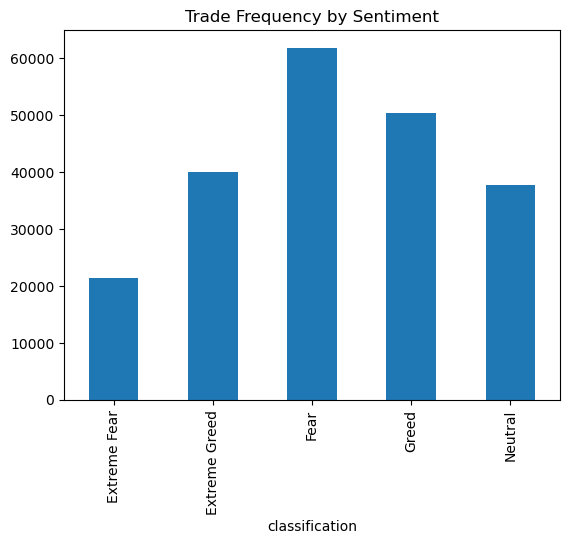

In [87]:
df.groupby('classification').size().plot(kind='bar')
plt.title("Trade Frequency by Sentiment")

#### Trade Frequency Analysis

The trade frequency analysis shows that trading activity is highest during Fear conditions, indicating that traders actively participate in volatile markets.

Greed phases also show high activity, suggesting continued engagement during bullish conditions.

However, trading activity drops significantly during Extreme Fear, indicating that traders may avoid the market during periods of extreme uncertainty and risk.

This demonstrates that market sentiment directly influences trader participation and behavior.

### PnL vs Market Sentiment
We analyze how profitability varies across sentiment conditions.

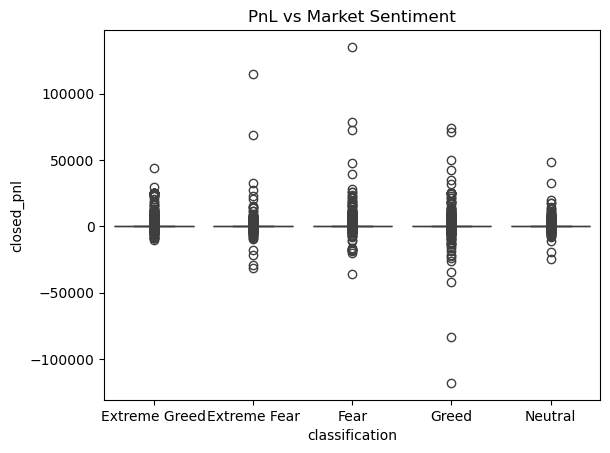

In [88]:
sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("PnL vs Market Sentiment")
plt.show()

#### Boxplot Interpretation

The PnL distribution across sentiment categories shows that most trades result in small gains or losses, as indicated by median values close to zero.

However, all sentiment categories exhibit extreme outliers, suggesting that a small number of trades contribute disproportionately to overall profitability.

Fear phases show high variability with both large gains and losses, indicating uncertain and volatile market conditions.

Greed phases exhibit extreme negative losses, suggesting that traders may take excessive risks due to overconfidence.

Neutral sentiment shows relatively lower dispersion, indicating more stable trading outcomes.

### Average PnL bar chart

Text(0.5, 1.0, 'Average PnL by Sentiment')

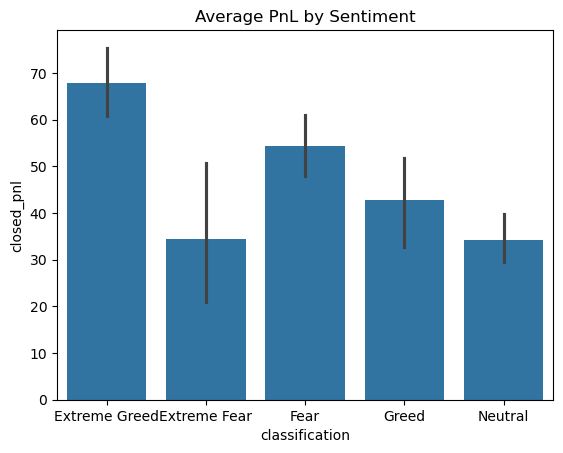

In [89]:
sns.barplot(x='classification', y='closed_pnl', data=df)
plt.title("Average PnL by Sentiment")

#### Average PnL Interpretation

The bar chart shows that Extreme Greed phases have the highest average PnL, followed by Fear and Greed conditions.

However, the large error bars indicate high variability in outcomes, meaning that profits are not consistent across trades.

Extreme Fear and Neutral conditions show lower average profitability, suggesting more conservative or less favorable trading environments.

When combined with the boxplot analysis, it is evident that higher average returns in Greed phases come with increased risk and potential for large losses.

#### Win rate

In [90]:

df.groupby('account')['is_profit'].mean()

account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    0.345912
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    0.306294
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0x

Text(0.5, 1.0, 'Win Rate by Sentiment')

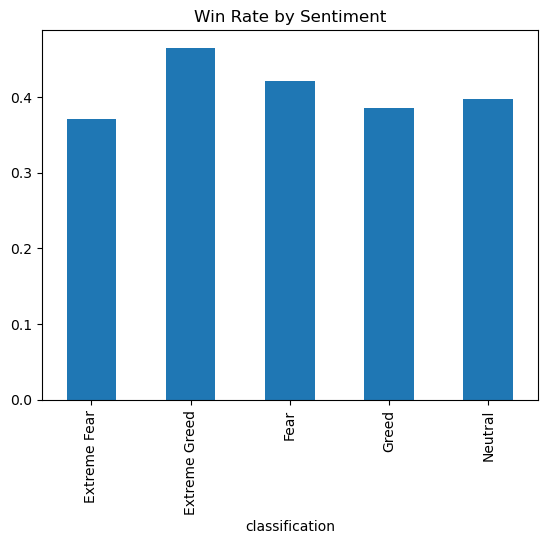

In [53]:
df.groupby('classification')['is_profit'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")

#### Win Rate Interpretation

The win rate analysis shows that Extreme Greed has the highest proportion of profitable trades, followed by Fear and Neutral conditions.

Extreme Fear exhibits the lowest win rate, indicating more challenging trading conditions.

However, despite higher win rates in Greed phases, the presence of extreme losses (as observed in the boxplot) suggests that profitability is not solely determined by win frequency but also by the magnitude of losses.

This highlights the importance of risk management over simply maximizing win rate.

### Trade Size Analysis

In [80]:
df.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

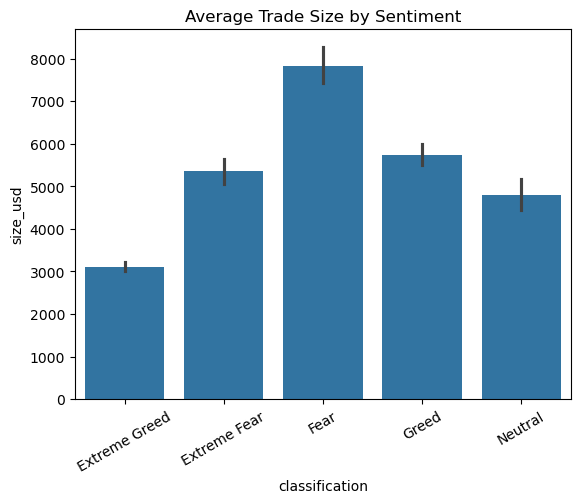

In [83]:
sns.barplot(x='classification', y='size_usd', data=df)
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=30)
plt.show()

### Trade Size Analysis

The bar chart shows that average trade size is highest during Fear conditions, indicating that traders take larger positions in volatile market environments.

Greed phases also exhibit relatively high trade sizes, suggesting continued risk-taking behavior.

However, Extreme Greed shows the lowest average trade size, indicating that traders may become cautious after strong upward market movements.

Neutral conditions show moderate trade sizes, reflecting balanced trading behavior.

Overall, market sentiment significantly influences position sizing, with higher volatility leading to increased risk-taking.

### Trade Direction

In [82]:
### Long vs Short Behavior

pd.crosstab(df['classification'], df['direction'], normalize='index')

direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0.000000,0.037710,0.291636,0.145654,0.00000,0.000234,0.327336,0.148318,0.048692,0.00000,0.000280,0.000140
Extreme Greed,0.000000,0.128326,0.179686,0.162457,0.00000,0.000175,0.157532,0.191613,0.179136,0.00000,0.000275,0.000800
Fear,0.000000,0.051862,0.279121,0.149118,0.00000,0.000226,0.288242,0.176060,0.054401,0.00000,0.000291,0.000679
Greed,0.000159,0.093136,0.158996,0.225076,0.00002,0.000318,0.169851,0.231875,0.118999,0.00002,0.000457,0.001093
Neutral,0.000000,0.076554,0.265165,0.155230,0.00000,0.000398,0.271241,0.168577,0.062251,0.00000,0.000318,0.000265


In [50]:
daily_metrics = df.groupby(['account', 'date']).agg({
    'closed_pnl': 'sum',
    'is_profit': 'mean',
    'size_usd': 'mean',
    'trade_id': 'count'
}).reset_index()

daily_metrics.rename(columns={
    'closed_pnl': 'daily_pnl',
    'is_profit': 'win_rate',
    'trade_id': 'num_trades'
}, inplace=True)

In [51]:
daily_metrics.head()

,account,date,daily_pnl,win_rate,size_usd,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27


In [47]:

### Trading Frequency

df.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

### 6. Trader Segmentation

We divide traders into different groups:
- High vs Low leverage
- Frequent vs Infrequent traders
- Winners vs Losers

### Frequent vs Infrequent Traders

In [48]:
trade_counts = df['account'].value_counts()

df['freq_group'] = df['account'].map(
    lambda x: 'High' if trade_counts[x] > 50 else 'Low'
)


### Winners vs Losers

In [ ]:
total_pnl = df.groupby('account')['closed_pnl'].sum()

df['trader_type'] = df['account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

### Frequent Treders performance

In [55]:
df.groupby(['freq_group', 'classification'])['closed_pnl'].mean()

freq_group  classification
High        Extreme Fear      34.537862
            Extreme Greed     67.892861
            Fear              54.290400
            Greed             42.743559
            Neutral           34.307718
Name: closed_pnl, dtype: float64

Frequent traders show higher average profitability during Extreme Greed and Fear phases, indicating that active traders are better able to capitalize on strong trends and volatile market conditions.

### Winners vs Losers

In [56]:
df.groupby(['trader_type', 'classification'])['closed_pnl'].mean()

trader_type  classification
Loser        Extreme Fear      -22.598398
             Extreme Greed      51.702381
             Fear               46.768567
             Greed            -202.027754
             Neutral            17.327765
Winner       Extreme Fear       37.989084
             Extreme Greed      68.000450
             Fear               54.792435
             Greed              54.444738
             Neutral            35.049780
Name: closed_pnl, dtype: float64

Losing traders experience significant losses during Greed phases, with the largest negative PnL observed in this condition. This suggests that overconfidence and poor risk management during bullish markets lead to substantial losses.

### 7. Key Insights

1. Trading activity and position sizes increase significantly during Fear phases, indicating that traders actively engage in volatile market conditions to capture price movements.

2. Greed phases exhibit extreme negative losses despite relatively higher win rates, suggesting that overconfidence leads to poor risk management and large drawdowns.

3. Fear conditions show both large gains and losses, highlighting high market uncertainty and increased risk exposure.

4. Most trades result in small PnL values, while a small number of extreme trades dominate overall profitability.

5. Trader segmentation reveals that losing traders incur the largest losses during Greed phases, while consistent winners maintain stable performance across all market conditions.

### 8. Strategy Recommendations

1. During Fear phases, traders should reduce leverage but can selectively increase participation, as volatility provides opportunities but also increases risk.

2. During Greed phases, traders should avoid over-leveraging and implement strict stop-loss strategies, as large losses are more frequent despite higher win rates.

3. Low-performing traders should limit trading during Greed conditions, as this phase shows the highest risk of significant losses for inconsistent traders.

4. Focus on risk management rather than trade frequency, as a small number of extreme losses can negate multiple profitable trades.

### 9. Conclusion

Market sentiment plays a critical role in shaping trader behavior, particularly in terms of risk-taking, trade frequency, and position sizing. 

Fear phases drive higher activity and larger trades due to volatility, while Greed phases often lead to overconfidence and significant losses.

Overall, profitability is influenced less by win rate and more by risk management, highlighting the importance of disciplined trading strategies in different market conditions.